In [2]:
import asteroid_spinprops.ssolib.dataprep as dprep
import asteroid_spinprops.ssolib.modelfit as mfit
import asteroid_spinprops.ssolib.periodest as pest
import asteroid_spinprops.ssolib.utils as utils

# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# import rocks

In [3]:
root = "/data/fink/spins/"
data_path = os.path.join(root, "data", "ephemerides_atlas_ztf_2025.01.parquet")
sso_keys_path = os.path.join(data_path, "ssoname_keys.pkl")


# data_path = os.path.join(os.path.join(os.getcwd(), "data/ephemerides_atlas_ztf_2025.01.parquet"))
# sso_keys_path = os.path.join(os.path.join(os.getcwd(), "data/ssoname_keys.pkl"))
sso_keys = pd.read_pickle(sso_keys_path)

In [4]:
name = "2001 UN66"  # super dense LC ZTF
name = "Iphthime"  # JTO double
name = "Antiope"  # Easy
# name = "Didymos" # boarf
cdata, reject = dprep.filter_sso_data(
    sso_name=name,
    path_to_data=data_path,
    pqdict=sso_keys,
)

In [5]:
len(cdata.cmagpsf[0])

2317

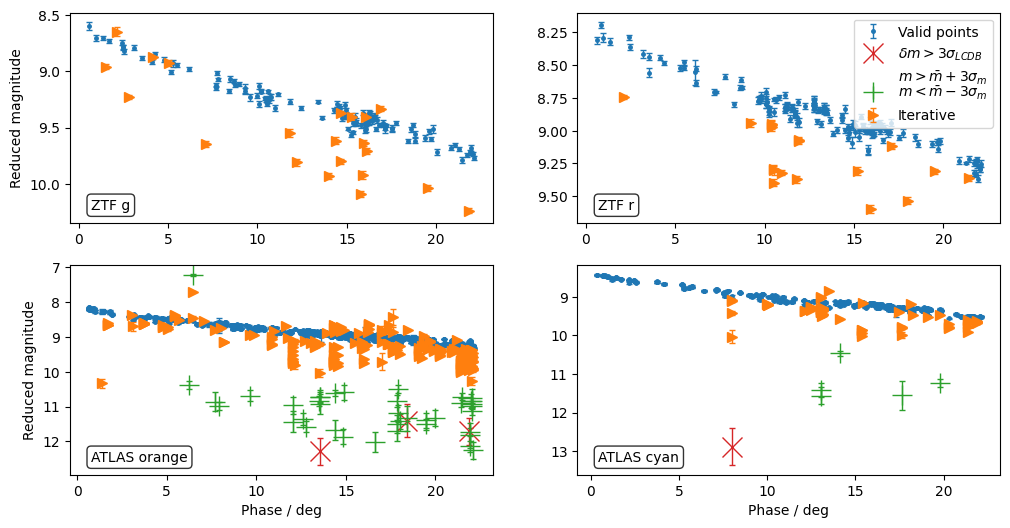

In [6]:
dprep.plot_filtering(cdata, reject)

In [7]:
shgg = mfit.get_fit_params(
    cdata,
    "SHG1G2",
)

In [8]:
rdf = mfit.make_residuals_df(cdata, shgg)

In [9]:
sg, w, n = pest.get_period_estimate(residuals_dataframe=rdf, p_min=0.03, p_max=2)

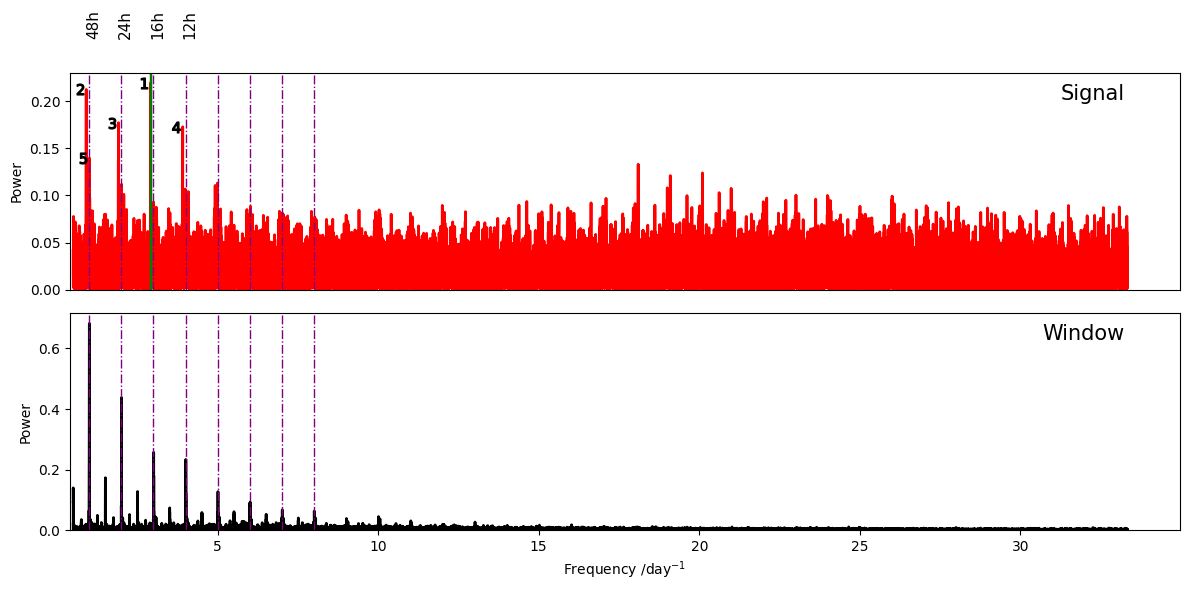

In [10]:
pest.plot_periodograms(sg, w, name)

In [11]:
_, Nbs = pest.perform_residual_resampling(resid_df=rdf)

In [12]:
print(Nbs)

7.0


In [13]:
P0 = 48 / sg[2][0]
P_selected = P0 / 24
P_selected * 24

np.float64(16.51114235813027)

In [14]:
sshgg = mfit.get_fit_params(
    cdata, "SSHG1G2", shg1g2_constrained=True, blind_scan=True, period_in=P_selected
)

In [18]:
cdata

,name,cmagpsf,csigmapsf,cjd,cfid,ciauobs,Dobs,Dhelio,Phase,Elong,ra,dec,px,py,pz,vx,vy,vz,cmred
0,Antiope,"[14.169, 14.186, 14.174, 14.187, 13.601, 13.61...","[0.01, 0.017, 0.009, 0.01, 0.018, 0.031, 0.021...","[2457430.11654, 2457430.12948, 2457430.13812, ...","[4, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 3, 3, 3, 3, ...","[T08, T08, T08, T08, T08, T08, T08, T08, T08, ...","[3.1876936, 3.1875036, 3.1873765, 3.187295, 2....","[2.971243, 2.9712224, 2.9712086, 2.9711995, 2....","[18.001352, 18.002663, 18.003536, 18.004099, 1...","[68.48949, 68.49881, 68.50502, 68.509026, 95.6...","[252.28175, 252.28584, 252.28857, 252.29033, 2...","[-21.925243, -21.925789, -21.926153, -21.92638...","[-0.89996374, -0.8997052, -0.8995327, -0.89942...","[-2.816861, -2.8167462, -2.8166697, -2.8166206...","[-1.1902738, -1.190231, -1.1902024, -1.1901839...","[0.019989107, 0.019968273, 0.01995485, 0.01994...","[0.008858188, 0.008850526, 0.00884461, 0.00884...","[0.003313095, 0.003314222, 0.0033149733, 0.003...","[9.286926120758057, 9.304070602416992, 9.29216..."


In [24]:
from fink_utils.sso.spins import (cos_aspect_angle)
import numpy as np

In [31]:
ra0 = float(sshgg[np.str_('alpha0')])
dec0 = float(sshgg[np.str_('delta0')])

W0 = float(sshgg[np.str_('phi0')])
W1 = 2*np.pi/float(sshgg[np.str_('period')])
t0 = 2459580.5

In [29]:
sshgg.keys()

dict_keys(['chi2red', 'min_cos_lambda', 'mean_cos_lambda', 'max_cos_lambda', 'status', 'fit', 'rms', 'rms_1', 'rms_2', 'rms_3', 'rms_4', 'median_error_phot', 'median_error_phot_1', 'median_error_phot_2', 'median_error_phot_3', 'median_error_phot_4', 'n_obs', 'n_obs_1', 'n_obs_2', 'n_obs_3', 'n_obs_4', 'min_phase', 'min_phase_1', 'min_phase_2', 'min_phase_3', 'min_phase_4', 'max_phase', 'max_phase_1', 'max_phase_2', 'max_phase_3', 'max_phase_4', np.str_('alpha0'), 'err_alpha0', np.str_('delta0'), 'err_delta0', np.str_('period'), 'err_period', np.str_('a_b'), 'err_a_b', np.str_('a_c'), 'err_a_c', np.str_('phi0'), 'err_phi0', np.str_('H_1'), 'err_H_1', np.str_('G1_1'), 'err_G1_1', np.str_('G2_1'), 'err_G2_1', np.str_('H_2'), 'err_H_2', np.str_('G1_2'), 'err_G1_2', np.str_('G2_2'), 'err_G2_2', np.str_('H_3'), 'err_H_3', np.str_('G1_3'), 'err_G1_3', np.str_('G2_3'), 'err_G2_3', np.str_('H_4'), 'err_H_4', np.str_('G1_4'), 'err_G1_4', np.str_('G2_4'), 'err_G2_4'])

In [ ]:
cos_aspect = cos_aspect_angle(np.radians(cdata.ra[0]), np.radians(cdata.dec[0]), np.radians(ra0), np.radians(dec0))

rot_phase = rotation_phase(cdata.cjd[0], W0, W1, t0):

sep_long = subobserver_longitude(np.radians(cdata.ra[0]), np.radians(cdata.dec[0]), np.radians(ra0), np.radians(dec0)), rot_phase)

/home/bcarry/anaconda3/envs/astro/lib/python3.12/site-packages/asteroid_spinprops/ssolib/modelfit.py:440: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


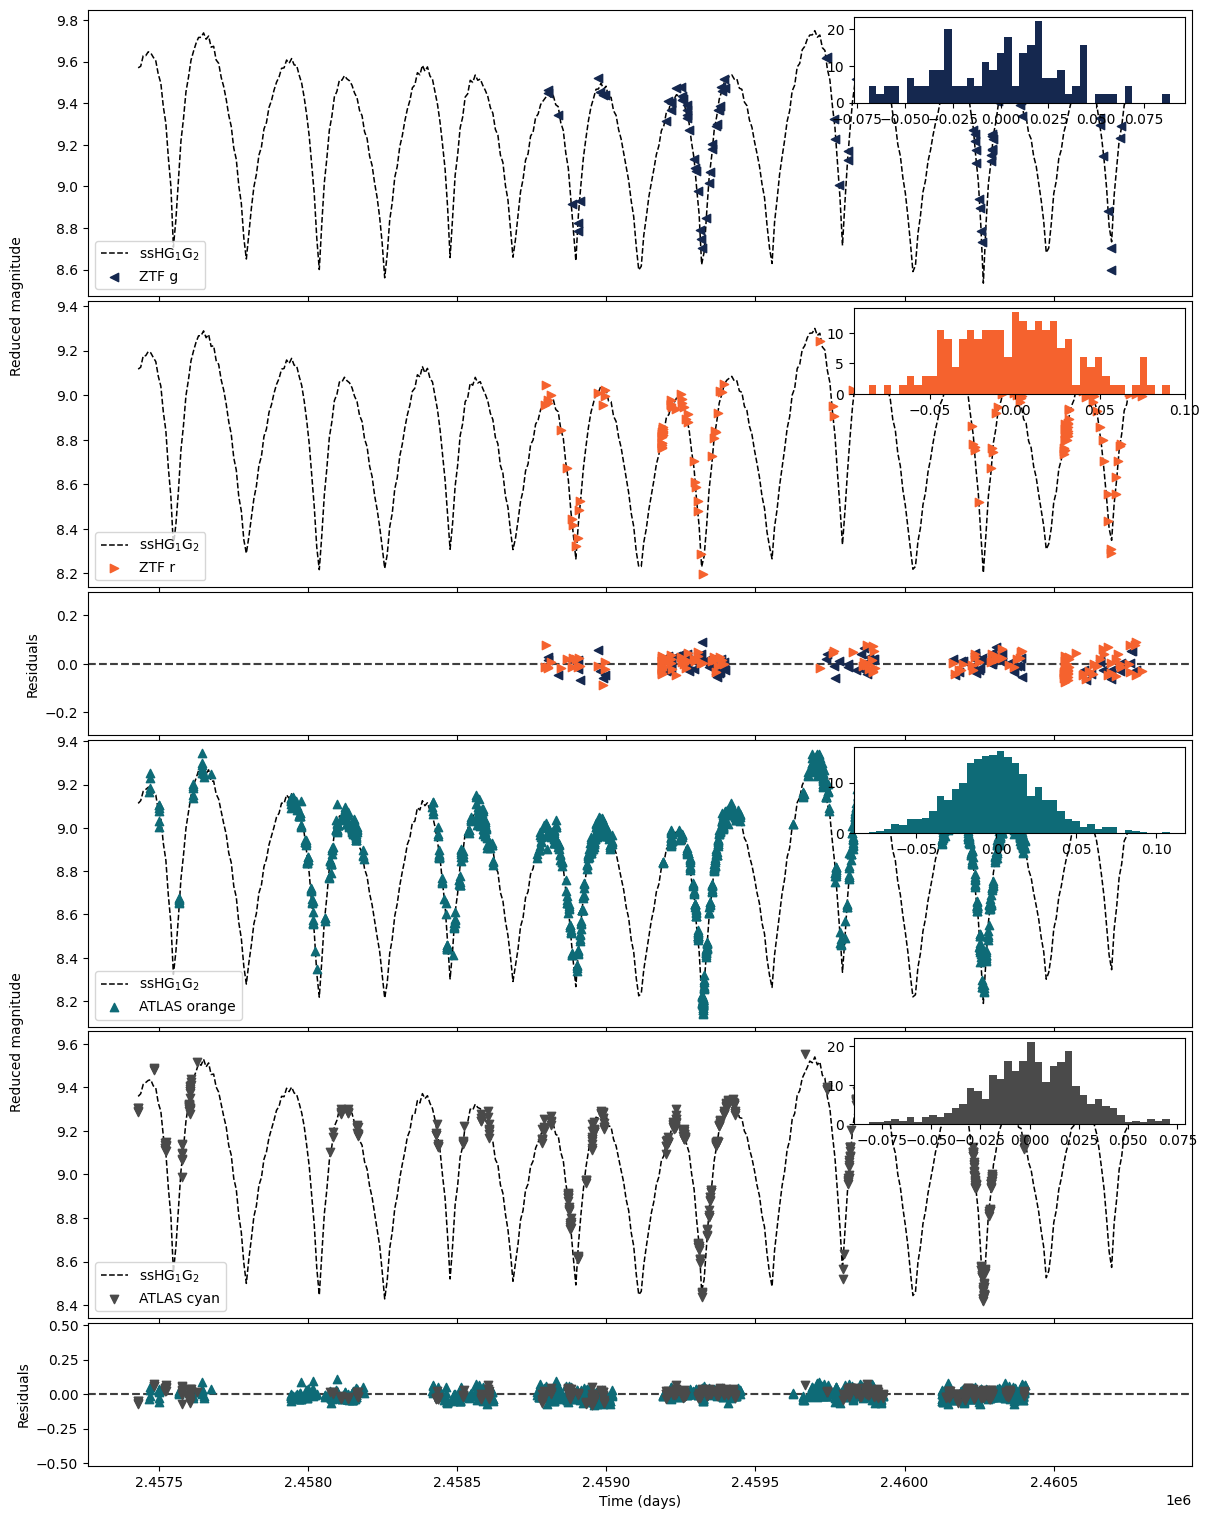

In [73]:
# import PyQt5
# %matplotlib qt
mfit.plot_model(cdata, "SSHG1G2", sshgg)

In [1]:
sshgg["period"] * 24, sshgg["a_b"], sshgg["a_c"]

NameError: name 'sshgg' is not defined

In [56]:
from fink_utils.sso.spins import extract_obliquity

psi = extract_obliquity([name], sshgg["alpha0"], sshgg["delta0"])

In [76]:
sshgg.keys()

dict_keys(['chi2red', 'min_cos_lambda', 'mean_cos_lambda', 'max_cos_lambda', 'status', 'fit', 'rms', 'rms_1', 'rms_2', 'rms_3', 'rms_4', 'median_error_phot', 'median_error_phot_1', 'median_error_phot_2', 'median_error_phot_3', 'median_error_phot_4', 'n_obs', 'n_obs_1', 'n_obs_2', 'n_obs_3', 'n_obs_4', 'min_phase', 'min_phase_1', 'min_phase_2', 'min_phase_3', 'min_phase_4', 'max_phase', 'max_phase_1', 'max_phase_2', 'max_phase_3', 'max_phase_4', np.str_('alpha0'), 'err_alpha0', np.str_('delta0'), 'err_delta0', np.str_('period'), 'err_period', np.str_('a_b'), 'err_a_b', np.str_('a_c'), 'err_a_c', np.str_('phi0'), 'err_phi0', np.str_('H_1'), 'err_H_1', np.str_('G1_1'), 'err_G1_1', np.str_('G2_1'), 'err_G2_1', np.str_('H_2'), 'err_H_2', np.str_('G1_2'), 'err_G1_2', np.str_('G2_2'), 'err_G2_2', np.str_('H_3'), 'err_H_3', np.str_('G1_3'), 'err_G1_3', np.str_('G2_3'), 'err_G2_3', np.str_('H_4'), 'err_H_4', np.str_('G1_4'), 'err_G1_4', np.str_('G2_4'), 'err_G2_4'])

In [57]:
psi

array([55.88683369])

In [58]:
utils.oblateness(sshgg["a_b"], sshgg["a_c"])

AttributeError: module 'asteroid_spinprops.ssolib.utils' has no attribute 'oblateness'

In [ ]:
sshgg["a_c"]

In [ ]:
0.6877 * 24

16.5048